# Advanced Performance

`PauliPropagation.jl` is designed to be modular, extensible, and easy to use at a high level. At the same time, we want to enable state-of-the-art Pauli propagation performance. This is a notebook explaining how to squeeze the most out of this library. 

In [17]:
using Pkg
Pkg.activate(".")
using PauliPropagation
using PauliPropagation.Performance
using Base.Threads
using Printf
using Plots

println("Threads.nthreads() = $(nthreads())")

Threads.nthreads() = 8


  Activating project at `~/Projects/PauliPropagation.jl/examples`


## A $6\times6$ tilted-field Ising circuit

We consider the example quantum circuits that corresponds to the Trotterized dynamics of a $6\times6$ tilted-field Ising Hamiltonian. One Trotter layer consists of single-qubit $R_x$ and $R_z$ rotations plus nearest-neighbour $R_{zz}$ rotations. The observable is $Z_{21}Z_{22}$ sitting right in the middle of the grid.

In [18]:
nx = 6
ny = 6
nq = nx * ny

dt = 0.05
h = 1.0
J = 0.5

topology = rectangletopology(nx, ny)
layer = PauliRotation[]
rxlayer!(layer, nq)
rzlayer!(layer, nq)
rzzlayer!(layer, topology)

thetas = ones(countparameters(layer)) * dt * 2

x_inds = getparameterindices(layer, PauliRotation, [:X])
z_inds = getparameterindices(layer, PauliRotation, [:Z])
zz_inds = getparameterindices(layer, PauliRotation, [:Z, :Z])
thetas[x_inds] .*= h
thetas[z_inds] .*= h
thetas[zz_inds] .*= J

pstr = PauliString(nq, [:Z, :Z], [21, 22])
min_abs_coeff = 2.0^(-20)

nlayers = 14;

## Switching to `VectorPauliSum`
Most of our examples use the `PauliSum` type, which stores Pauli strings and their coefficients in a `Dict`. It is flexible and generally a robust choice. Our first performance suggestion is to switch to `VectorPauliSum`, which stores Pauli strings and their coefficients in two `Vector`s. This is generally faster for non-branching gates such as `CliffordGate` and `DepolarizingNoise`, but we also have optimized code for the very common `PauliRotation` gate.

Let us run all 14 layers with either type.

In [19]:
circuit = repeat(layer, nlayers)
circuit_thetas = repeat(thetas, nlayers)

# one layer up front so that the timings below are not dominated by compilation
propagate(layer, PauliSum(pstr), thetas; min_abs_coeff)
propagate(layer, VectorPauliSum(pstr), thetas; min_abs_coeff)

t_dict = @elapsed dict_psum = propagate(circuit, PauliSum(pstr), circuit_thetas; min_abs_coeff)
t_vec = @elapsed vec_psum = propagate(circuit, VectorPauliSum(pstr), circuit_thetas; min_abs_coeff)

@printf("PauliSum:        %5.2f s   (%d Pauli terms)\n", t_dict, length(dict_psum))
@printf("VectorPauliSum:  %5.2f s   (%d Pauli terms)\n", t_vec, length(vec_psum))

PauliSum:        15.58 s   (1036142 Pauli terms)
VectorPauliSum:   4.25 s   (1036142 Pauli terms)


Both give the same expectation value $\langle Z_{21} Z_{22}\rangle$.

In [20]:
overlapwithzero(dict_psum), overlapwithzero(vec_psum)

(0.6696851623009783, 0.6696851623009762)

## Threading

Both `VectorPauliSum` runs above were multi-threaded, which is the default. `thread=false` forces a single threaded propagation. Threading pays off once the Pauli sum is large enough that the work per task outweighs the cost of spawning tasks. It is also the wrong choice if you already parallelize at a higher level, because the nested tasks would only compete for the same cores.

In [21]:
t_serial = @elapsed propagate(circuit, VectorPauliSum(pstr), circuit_thetas; min_abs_coeff, thread=false)

@printf("thread=false:  %5.2f s\n", t_serial)
@printf("thread=true:   %5.2f s\n", t_vec)

thread=false:   7.30 s
thread=true:    4.25 s


## Propagating in-place with `PropagationCache`

`propagate` returns a fresh Pauli sum on every call. A Trotterized time evolution applies the same layer over and over, and usually wants an expectation value after every step, so we would rather advance one Pauli sum in place. That is what `PropagationCache` and `propagate!` are for.

The cache holds a main and an auxiliary Pauli sum, plus a few scratch arrays. Every `propagate!` call writes into the auxiliary sum and then swaps the two, so no new memory is needed in between. `resize!(prop_cache, N)` grows all of these arrays once up front, with `N` a generous estimate of the final number of Pauli terms, so that they do not have to grow during the run.

Expectation values can be read straight off the cache with `overlapwithzero(prop_cache)`, without extracting a Pauli sum.

In [22]:
prop_cache = PropagationCache(VectorPauliSum(pstr))
resize!(prop_cache, 1_500_000)

expectations = Float64[]
nterms = Int[]

t_cache = @elapsed for l in 1:nlayers
    propagate!(layer, prop_cache, thetas; min_abs_coeff)
    push!(expectations, overlapwithzero(prop_cache))
    push!(nterms, length(prop_cache))
end

@printf("propagate! into a cache:  %5.2f s   (%d Pauli terms)\n", t_cache, length(prop_cache))

propagate! into a cache:   3.94 s   (1036142 Pauli terms)


The whole time series comes out of that single sweep.

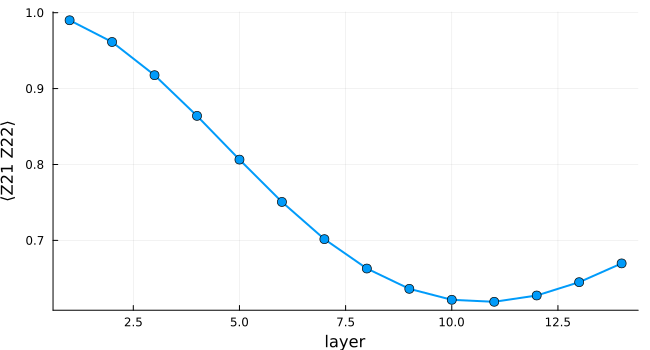

In [23]:
plot(1:nlayers, expectations, xlabel="layer", ylabel="⟨Z21 Z22⟩", legend=false,
    linewidth=2, marker=:circle, markersize=5, size=(650, 350))

## Fused kernels in `PauliPropagation.Performance`

`PauliPropagation.Performance` is an opt-in module with fused versions of `propagate` and `propagate!` for `VectorPauliSum` that are somewhat experimental. Please report any issues you encounter via the issue tracker. Passing `fused=false` falls back to the default behavior.

In [24]:
fused_cache = PropagationCache(VectorPauliSum(pstr))
resize!(fused_cache, 1_500_000)

# one layer on a throwaway cache to compile the fused kernels
Performance.propagate!(layer, PropagationCache(VectorPauliSum(pstr)), thetas; min_abs_coeff)

t_fused = @elapsed for l in 1:nlayers
    Performance.propagate!(layer, fused_cache, thetas; min_abs_coeff)
end

@printf("Performance.propagate!:  %5.2f s   (%d Pauli terms)\n", t_fused, length(fused_cache))
@printf("⟨Z21 Z22⟩ = %.14f  vs  %.14f\n", overlapwithzero(fused_cache), expectations[end])

Performance.propagate!:   0.93 s   (1036142 Pauli terms)
⟨Z21 Z22⟩ = 0.66968516230098  vs  0.66968516230098


## Not all gates cost the same

A `PauliRotation` only branches the Pauli strings that anticommute with its generator, and leaves the rest untouched. What a gate costs therefore depends on where it sits. Take the Pauli sum after all 14 layers and apply a single $R_{zz}$ rotation to it, once at a corner of the grid and once in the middle where the observable lives. In the middle, a good fraction of the sum branches; at the corner, the few branches that appear fall below `min_abs_coeff` right away.

In [25]:
snapshot = VectorPauliSum(fused_cache)
n = length(snapshot)
theta = 2 * dt * J

edge_gate = PauliRotation([:Z, :Z], [1, 2])
mid_gate = PauliRotation([:Z, :Z], [21, 22])

edge_cache = PropagationCache(deepcopy(snapshot))
resize!(edge_cache, 2n)
mid_cache = PropagationCache(deepcopy(snapshot))
resize!(mid_cache, 2n)

# one gate on a throwaway cache to compile, again
Performance.propagate!(edge_gate, PropagationCache(VectorPauliSum(pstr)), theta; min_abs_coeff)

t_edge = @elapsed Performance.propagate!(edge_gate, edge_cache, theta; min_abs_coeff)
t_mid = @elapsed Performance.propagate!(mid_gate, mid_cache, theta; min_abs_coeff)

@printf("Rzz on qubits (1, 2):    %5.0f M Paulis/s   (%d -> %d terms)\n", n / t_edge / 1e6, n, length(edge_cache))
@printf("Rzz on qubits (21, 22):  %5.0f M Paulis/s   (%d -> %d terms)\n", n / t_mid / 1e6, n, length(mid_cache))

Rzz on qubits (1, 2):     1398 M Paulis/s   (1036142 -> 1036142 terms)
Rzz on qubits (21, 22):    106 M Paulis/s   (1036142 -> 1047250 terms)


## Before and after

Let us count how many Paulis we work through per second while we apply our gates. 

In [26]:
napplied = length(layer) * sum([1; nterms[1:end-1]])

labels = ["PauliSum", "VectorPauliSum\nserial", "VectorPauliSum\nthreaded", "+ propagate!\ninto a cache", "+ Performance\nfused"]
times = [t_dict, t_serial, t_vec, t_cache, t_fused]
rates = napplied ./ times ./ 1e6

@printf("%d gate applications on Pauli strings in total\n\n", napplied)
for (l, t, r) in zip(labels, times, rates)
    @printf("%-28s %6.2f s   %6.1f M Paulis/s\n", replace(l, "\n" => " "), t, r)
end

200640660 gate applications on Pauli strings in total

PauliSum                      15.58 s     12.9 M Paulis/s
VectorPauliSum serial          7.30 s     27.5 M Paulis/s
VectorPauliSum threaded        4.25 s     47.2 M Paulis/s
+ propagate! into a cache      3.94 s     50.9 M Paulis/s
+ Performance fused            0.93 s    215.8 M Paulis/s


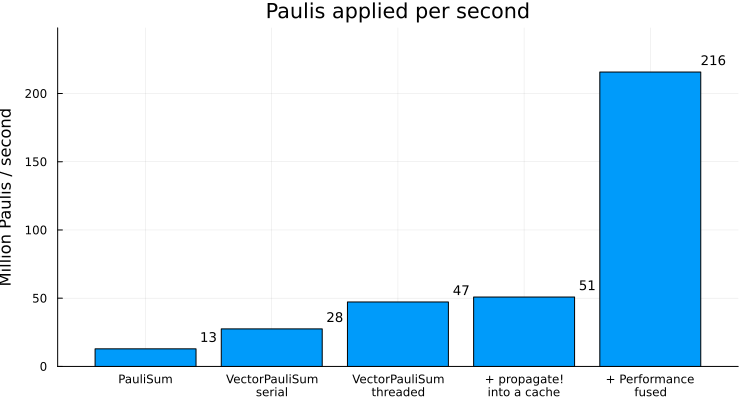

In [27]:
p = bar(labels, rates, legend=false, ylabel="Million Paulis / second", size=(750, 400),
    ylims=(0, 1.15 * maximum(rates)), title="Paulis applied per second")
annotate!(p, 1:length(rates), rates .+ 0.04 * maximum(rates), [text(@sprintf("%.0f", r), 9) for r in rates])
p

## Summary

Switch to `VectorPauliSum` once your Pauli sums reach hundreds of thousands of terms, and let it thread unless you are already parallelizing somewhere above. For layered evolution, keep a `PropagationCache`, `resize!` it up front, advance it with `propagate!`, and estimate the observables off the cache after every layer. If you need to squeeze out all the performance this library has to offer, `PauliPropagation.Performance` has fused kernels for exactly that.